## Clustering with Hierarchical clustering

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# Load the CSV file into a DataFrame
file_path = 'data/artisans_data.csv'  # Update this with the path to your file
artisan_data = pd.read_csv(file_path, low_memory=False)


In [3]:
artisan_geodata = gpd.GeoDataFrame(artisan_data, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

In [4]:
artisan_geodata.rename(
    columns={
        "Name": "name",
        "Address": "address",
        "Latitude": "latitude",
        "Longitude": "longitude",
    }, inplace = True
)

In [5]:
artisan_geodata.head()

,name,address,longitude,latitude,geometry
0,Professional Locksmiths Association Of Nigeria...,"Banex Plaza, National Secretariat, Itire, 57 I...",3.502969,6.617908,POINT (3.50297 6.61791)
1,GT LOCKSMITH KEY DUPLICATING PROGRAMMER FOB BA...,"Block 13/14, Igbo-Efon, Lekki - Epe Expy, Lekk...",3.411717,6.449054,POINT (3.41172 6.44905)
2,Major Locksmith Nigeria Limited,"Kiosk, Tafawa Balewa Square Complex, Race Cour...",3.401122,6.445246,POINT (3.40112 6.44525)
3,Phymocool Car AC Repair & Installation,"29 Balogun St, Yaba 100001, Lagos, Nigeria, La...",3.377044,6.534158,POINT (3.37704 6.53416)
4,OFTECH,"162 Borno Way, Lagos, Lagos",3.376426,6.500482,POINT (3.37643 6.50048)


In [18]:
from sklearn.cluster import AgglomerativeClustering

# Convert coordinates to a 2D array
coords = artisan_geodata[['longitude', 'latitude']].values

# Apply Hierarchical Clustering
hierarchical_clustering = AgglomerativeClustering(n_clusters=10, linkage='ward')
artisan_geodata['cluster'] = hierarchical_clustering.fit_predict(coords)

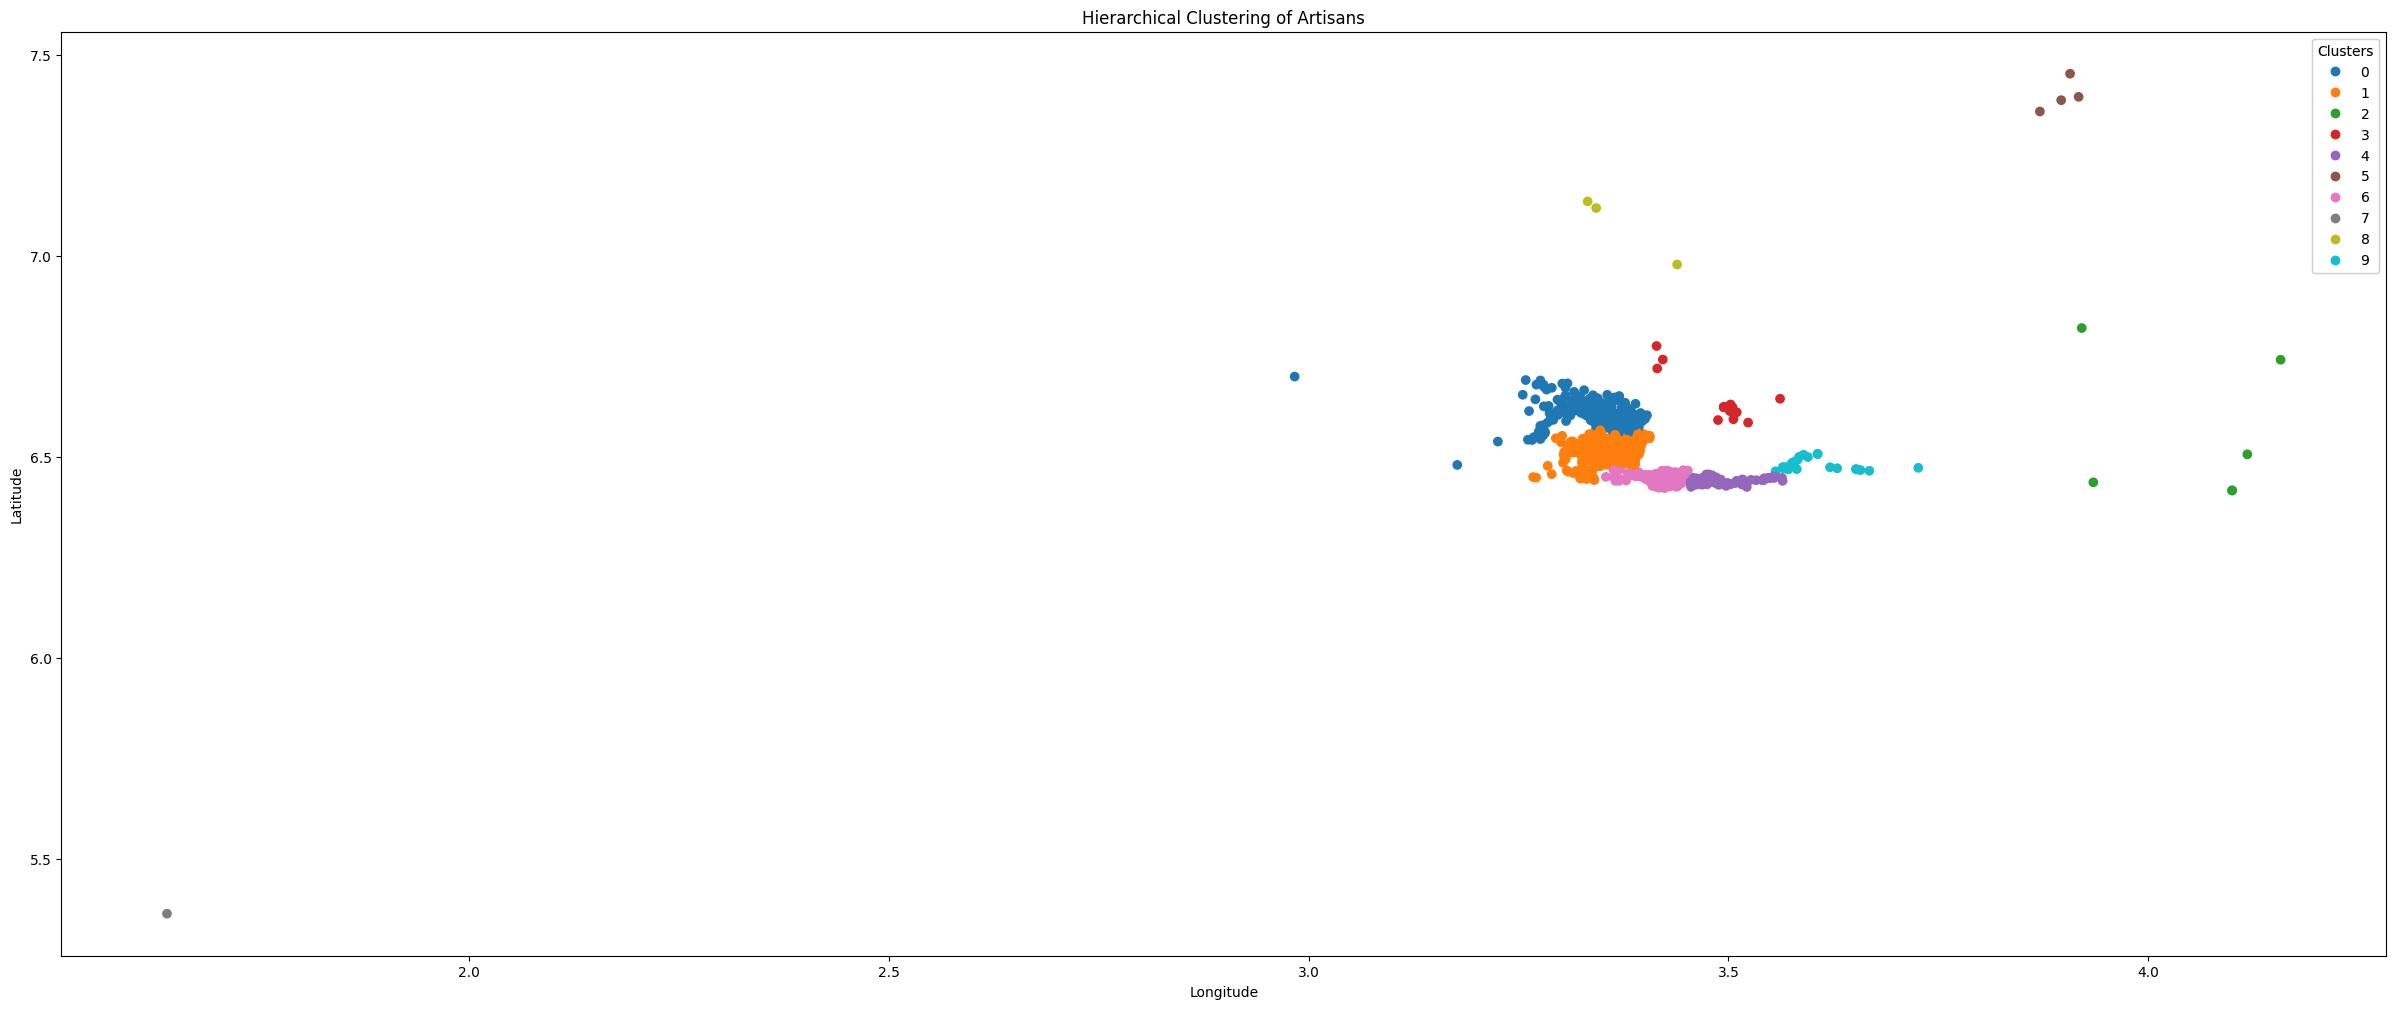

In [20]:
# Plot the clusters
fig, ax = plt.subplots(figsize=(30, 12))
scatter = ax.scatter(artisan_geodata['longitude'], artisan_geodata['latitude'], c=artisan_geodata['cluster'], cmap='tab10')
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)
plt.title('Hierarchical Clustering of Artisans')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [21]:
import folium
from folium.plugins import MarkerCluster

In [22]:
m = folium.Map(location=[artisan_geodata['latitude'].mean(), artisan_geodata['longitude'].mean()], zoom_start=12)

In [23]:
# Add marker clusters to the map
marker_cluster = MarkerCluster().add_to(m)

# Define a color palette for the clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']

# Add the artisans to the marker cluster
for idx, row in artisan_geodata.iterrows():
    folium.Marker(location=[row['latitude'], row['longitude']],
                  popup=f"Name: {row['name']}\nCluster: {row['cluster']}",
                  icon=folium.Icon(color=colors[row['cluster'] % len(colors)])
                 ).add_to(marker_cluster)

# Save the map to an HTML file
m.save("clusters_map.html")

In [24]:
m

In [25]:
# Using Plotly for Graphing

import plotly.express as px

In [26]:
artisan_dataframe = pd.DataFrame({
    'Name': artisan_geodata['name'],
    'Address': artisan_geodata['address'],
    'Lat': artisan_geodata['latitude'],
    'Long': artisan_geodata['longitude'],
    'Cluster': artisan_geodata['cluster']
})

In [27]:
color_scale = px.colors.qualitative.Plotly

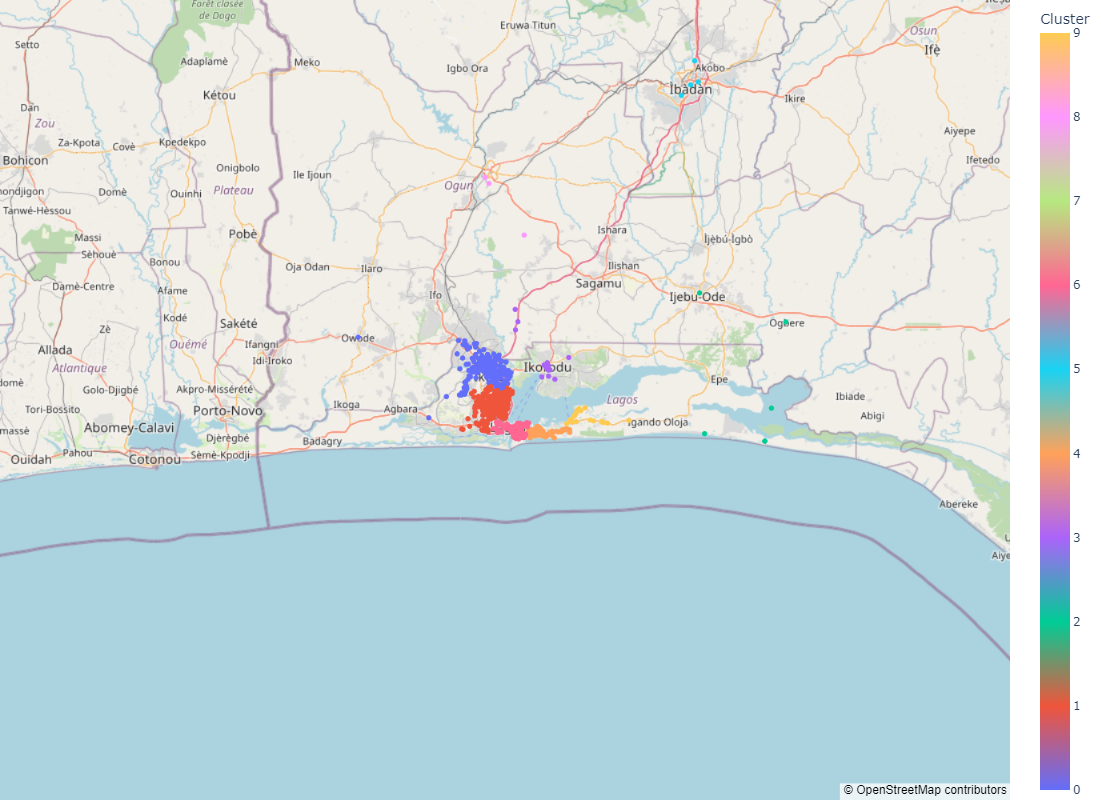

In [28]:
fig = px.scatter_mapbox(artisan_dataframe, 
                        lat="Lat", 
                        lon="Long", 
                        hover_name="Name", 
                        hover_data=["Name", "Address", "Cluster"],
                        color="Cluster",
                        color_continuous_scale=color_scale,
                        size_max=15,
                        zoom=8, 
                        height=800,
                        width=800)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()